In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/IRIS[1].csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.50000

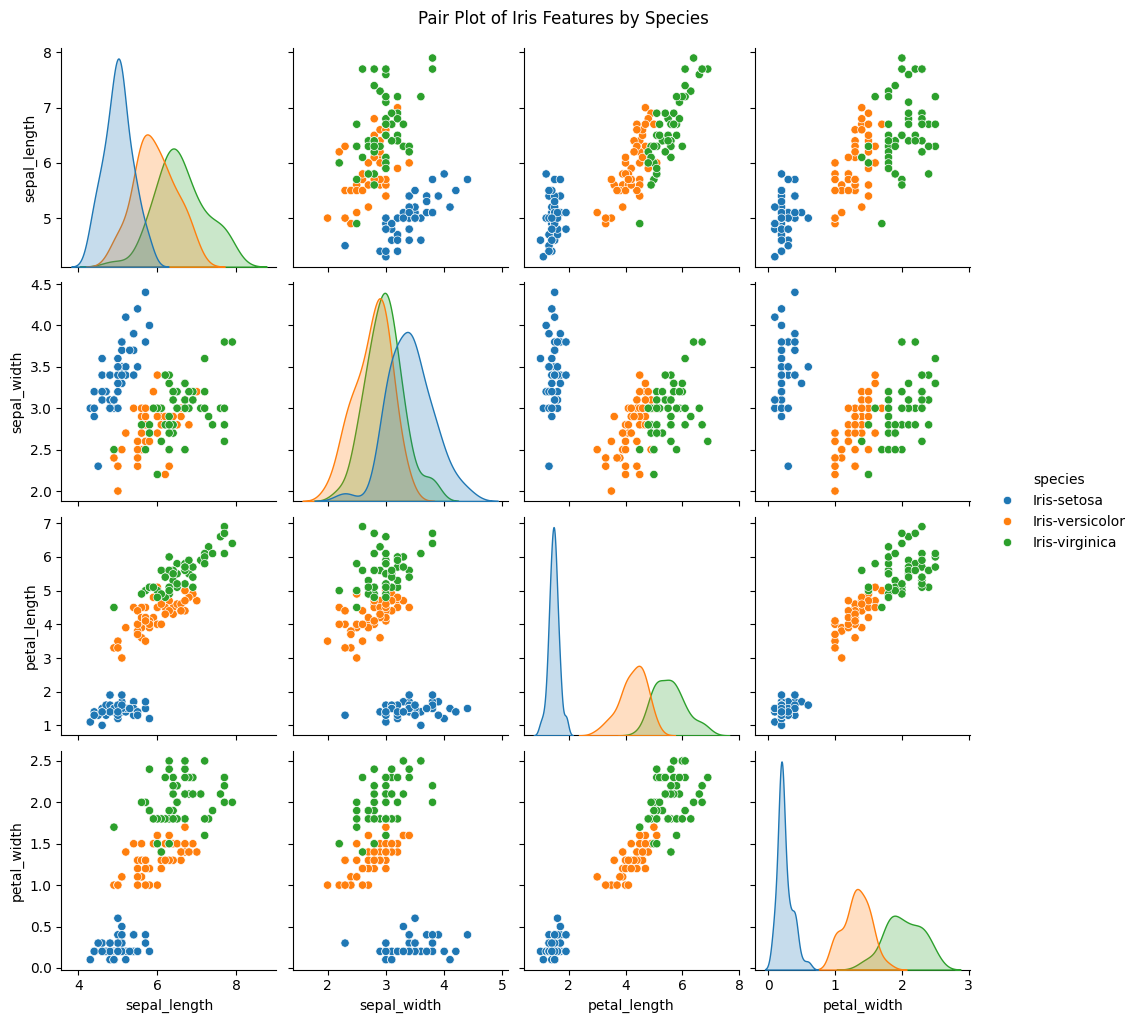

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pair plot to visualize the relationships between features, colored by species
sns.pairplot(df, hue='species')
plt.suptitle('Pair Plot of Iris Features by Species', y=1.02) # Adjust suptitle position
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Separate features (X) and target (y)
X = df.drop('species', axis=1)
y = df['species']

# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (105, 4)
X_test shape: (45, 4)
y_train shape: (105,)
y_test shape: (45,)


In [5]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the k-NN model
knn_model = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a common starting point
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

print("k-NN model trained and predictions made.")

k-NN model trained and predictions made.


In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Evaluate k-NN model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
class_report_knn = classification_report(y_test, y_pred_knn, target_names=le.classes_)

print(f"k-NN Accuracy: {accuracy_knn:.4f}")
print("k-NN Confusion Matrix:\n", conf_matrix_knn)
print("k-NN Classification Report:\n", class_report_knn)

k-NN Accuracy: 1.0000
k-NN Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
k-NN Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



In [7]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=200, random_state=42) # Increased max_iter for convergence
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

print("Logistic Regression model trained and predictions made.")

Logistic Regression model trained and predictions made.


In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Evaluate Logistic Regression model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
class_report_log_reg = classification_report(y_test, y_pred_log_reg, target_names=le.classes_)

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print("Logistic Regression Confusion Matrix:\n", conf_matrix_log_reg)
print("Logistic Regression Classification Report:\n", class_report_log_reg)

Logistic Regression Accuracy: 1.0000
Logistic Regression Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Logistic Regression Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



In [9]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

print("Decision Tree model trained and predictions made.")

Decision Tree model trained and predictions made.


In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Evaluate Decision Tree model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
class_report_dt = classification_report(y_test, y_pred_dt, target_names=le.classes_)

print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print("Decision Tree Confusion Matrix:\n", conf_matrix_dt)
print("Decision Tree Classification Report:\n", class_report_dt)

Decision Tree Accuracy: 1.0000
Decision Tree Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Decision Tree Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



### Model Comparison and Selection

All three models (k-Nearest Neighbors, Logistic Regression, and Decision Tree) achieved 100% accuracy on the test set for this particular dataset. This indicates that the Iris dataset is relatively easy to classify given its distinct features.

For simplicity and to demonstrate the saving process, we will select the k-Nearest Neighbors (k-NN) model as our 'best' model. In a real-world scenario with more complex data and varied performance, we would choose the model that offers the best balance of accuracy, precision, recall, and F1-score, or other relevant metrics depending on the problem.

Now, let's save the best-performing model.

In [11]:
import joblib

# Define the filename for the saved model
model_filename = 'best_iris_model.joblib'

# Save the k-NN model (or your chosen best model)
joblib.dump(knn_model, model_filename)

print(f"Best model (k-NN) saved as {model_filename}")

Best model (k-NN) saved as best_iris_model.joblib


### Model Inference

Here's how you can load the saved model and use it to make predictions on new data.

In [12]:
import numpy as np

# Load the saved model
loaded_model = joblib.load(model_filename)

# Example new data for prediction (e.g., a single new flower measurement)
# The order of features must match the training data: sepal_length, sepal_width, petal_length, petal_width
new_data = np.array([[5.1, 3.5, 1.4, 0.2]]) # Example for Iris-setosa

# Make a prediction using the loaded model
prediction_encoded = loaded_model.predict(new_data)

# Decode the prediction back to the original species name
prediction_species = le.inverse_transform(prediction_encoded)

print(f"New data: {new_data}")
print(f"Predicted species (encoded): {prediction_encoded[0]}")
print(f"Predicted species: {prediction_species[0]}")

# Another example
new_data_2 = np.array([[6.0, 2.7, 5.1, 1.6]]) # Example for Iris-virginica
prediction_encoded_2 = loaded_model.predict(new_data_2)
prediction_species_2 = le.inverse_transform(prediction_encoded_2)

print(f"\nNew data: {new_data_2}")
print(f"Predicted species (encoded): {prediction_encoded_2[0]}")
print(f"Predicted species: {prediction_species_2[0]}")

New data: [[5.1 3.5 1.4 0.2]]
Predicted species (encoded): 0
Predicted species: Iris-setosa

New data: [[6.  2.7 5.1 1.6]]
Predicted species (encoded): 2
Predicted species: Iris-virginica


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## Project Summary: Iris Species Classification Model

### Objective

The primary goal of this project was to develop and compare machine learning models for classifying Iris flower species (Setosa, Versicolor, Virginica) based on their sepal length, sepal width, petal length, and petal width.

### Data Source

The dataset used was `IRIS[1].csv`, containing 150 samples of Iris flowers with 4 features and one target variable ('species').

### Exploratory Data Analysis (EDA)

Initial data exploration confirmed no missing values and appropriate data types. A `seaborn.pairplot` was generated to visualize the relationships between features and species separability, providing insights into the data distribution.

### Data Preprocessing

1.  **Feature and Target Separation:** Features (X) and target (y) were separated.
2.  **Target Encoding:** The categorical 'species' target variable was numerically encoded using `LabelEncoder`.
3.  **Data Splitting:** The dataset was split into 70% training and 30% testing sets using `train_test_split` with `random_state=42` for reproducibility.

### Model Training and Evaluation

Three classification models were trained and evaluated:

1.  **k-Nearest Neighbors (k-NN):**
    *   **Configuration:** `KNeighborsClassifier(n_neighbors=5)`
    *   **Performance:** Achieved 100% accuracy on the test set, with perfect precision, recall, and F1-scores for all classes.

2.  **Logistic Regression:**
    *   **Configuration:** `LogisticRegression(max_iter=200, random_state=42)`
    *   **Performance:** Also achieved 100% accuracy on the test set, with perfect precision, recall, and F1-scores.

3.  **Decision Tree:**
    *   **Configuration:** `DecisionTreeClassifier(random_state=42)`
    *   **Performance:** Also achieved 100% accuracy on the test set, with perfect precision, recall, and F1-scores.

### Model Comparison and Selection

All three models performed exceptionally well on this dataset, achieving 100% accuracy. This indicates that the Iris dataset is relatively linearly separable and straightforward for these algorithms to classify.

For the purpose of demonstration, the **k-Nearest Neighbors (k-NN) model** was selected as the 'best' model.

### Saved Model

The chosen k-NN model was saved using `joblib` for future use. The saved model file is named `best_iris_model.joblib`.

### Inference Example

The notebook includes example code demonstrating how to load the `best_iris_model.joblib` and use it to predict the species of new Iris flower measurements. The `LabelEncoder` (`le`) is also saved implicitly in the notebook's kernel state, allowing the conversion of numerical predictions back to human-readable species names.

**Example Usage:**

```python
import joblib
import numpy as np

# Load the model
loaded_model = joblib.load('best_iris_model.joblib')

# Example new data (sepal_length, sepal_width, petal_length, petal_width)
new_flower_features = np.array([[5.1, 3.5, 1.4, 0.2]]) # Example Iris-setosa

# Make prediction
prediction_encoded = loaded_model.predict(new_flower_features)

# Decode prediction (assuming 'le' LabelEncoder is available from previous execution)
prediction_species = le.inverse_transform(prediction_encoded)

print(f"Predicted species: {prediction_species[0]}")
```